# Orange County Analysis

In [1]:
# Import statements
import pandas as pd

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [2]:
# Load in policing data
original_policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2022_2024.csv", low_memory=False)

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "year",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "action_any_search",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = original_policing[[c for c in keep_cols if c in original_policing.columns]].copy()

In [3]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [4]:
from rates_utils import load_census, census_rollup

# Load in census data
census = load_census("06059")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = census_rollup(census)

# Policing Analysis

In [ ]:
from rates_utils import add_standardized_race, policing_rates

# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])].copy()

# Add standardized race column to match policing and prosecution labels
policing = add_standardized_race(policing, "race_ethnicity")

# Consider only purely discretionary searches in search and hit rates

# Clean contraband_any (handles NaN, 0/1, True/False)
policing["contraband_any"] = policing["contraband_any"].fillna(0).astype(int)

# Create discretionary search indicator
policing["disc_search"] = policing["search_type"].eq("Discretionary only")

# Create hits among discretionary searches indicator
policing["disc_hit"] = policing["disc_search"] & policing["contraband_any"].eq(1)

policing_analysis = policing_rates(policing, census_coarse)
policing_analysis

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Population,"Stops per 1,000","Searches per 1,000"
0,2022,Asian,20489,580,188,0.028308,0.324138,699124,29.306675,0.829610
1,2022,Black/African American,9361,930,266,0.099348,0.286022,49304,189.862891,18.862567
2,2022,Hispanic/Latino,76666,7549,2341,0.098466,0.310107,1086834,70.540671,6.945863
3,2022,Other,10946,332,95,0.030331,0.286145,153072,71.508832,2.168914
4,2022,White,65084,4260,1627,0.065454,0.381925,1198655,54.297525,3.553983
5,2023,Asian,18822,537,164,0.028530,0.305400,699124,26.922263,0.768104
6,2023,Black/African American,8400,789,197,0.093929,0.249683,49304,170.371572,16.002758
7,2023,Hispanic/Latino,68576,7004,1913,0.102135,0.273130,1086834,63.097032,6.444406
8,2023,Other,9753,271,64,0.027786,0.236162,153072,63.715114,1.770409
9,2023,White,55658,3471,1312,0.062363,0.377989,1198655,46.433711,2.895746


## Prosecution Rates

In [6]:
from rates_utils import prosecution_rates_by_statute_level

# Standardize race labels to match with policing data
prosecution = add_standardized_race(prosecution, "canonical_race")

# Create race x year x statute_level prosecution summary table
prosecution_analysis = prosecution_rates_by_statute_level(prosecution)

prosecution_analysis

,Canonical Race,Year,statute_level,Total Charges,Enhancement Rate
0,Asian,2021,Felony,1251,0.000799
1,Asian,2021,Misdemeanor,2768,0.142702
2,Asian,2022,Felony,1090,0.003670
3,Asian,2022,Misdemeanor,2289,0.174749
4,Asian,2023,Felony,876,0.001142
5,Asian,2023,Misdemeanor,1325,0.163774
6,Black/African American,2021,Felony,1689,0.008289
7,Black/African American,2021,Misdemeanor,3014,0.112143
8,Black/African American,2022,Felony,2195,0.006834
9,Black/African American,2022,Misdemeanor,2881,0.112114


# Visualizations

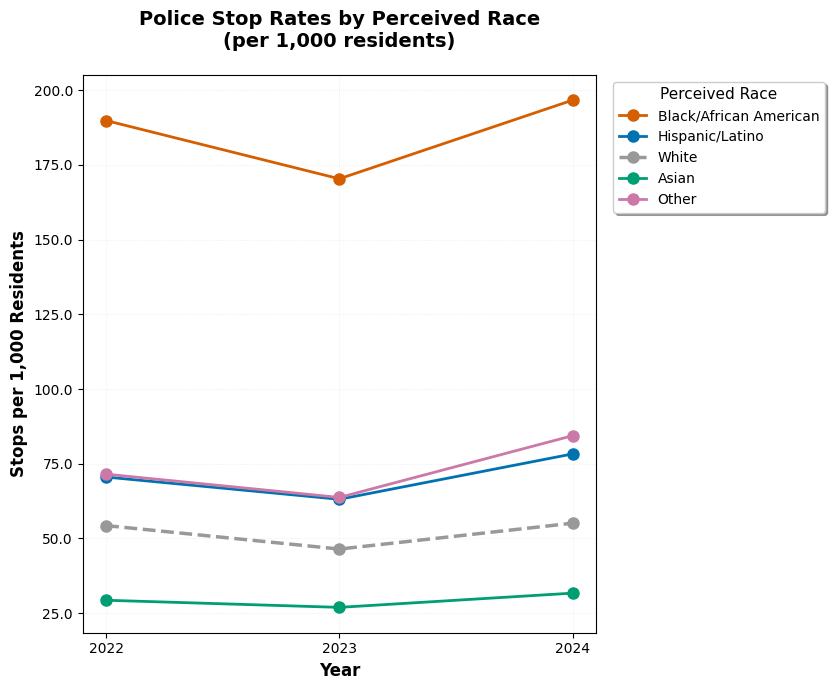

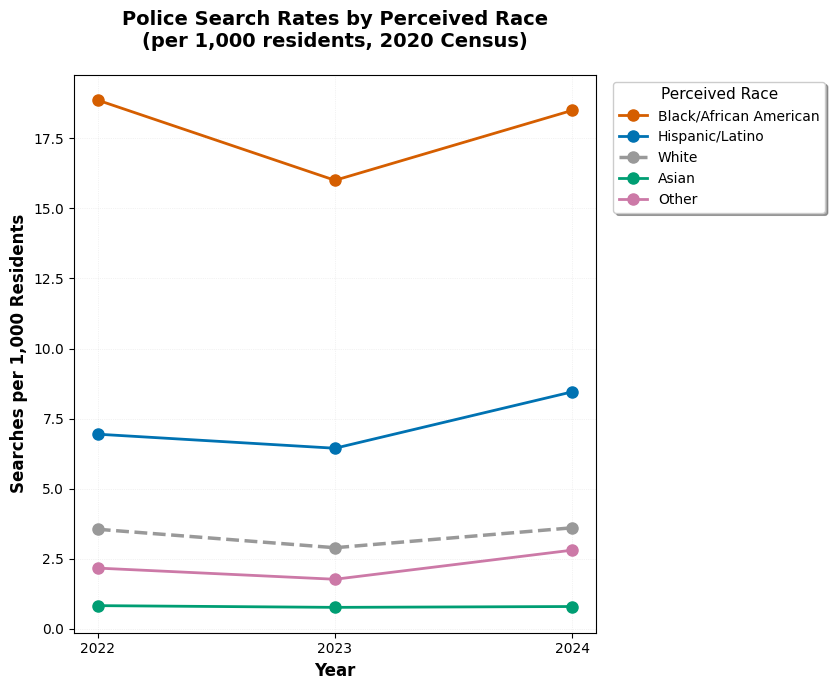

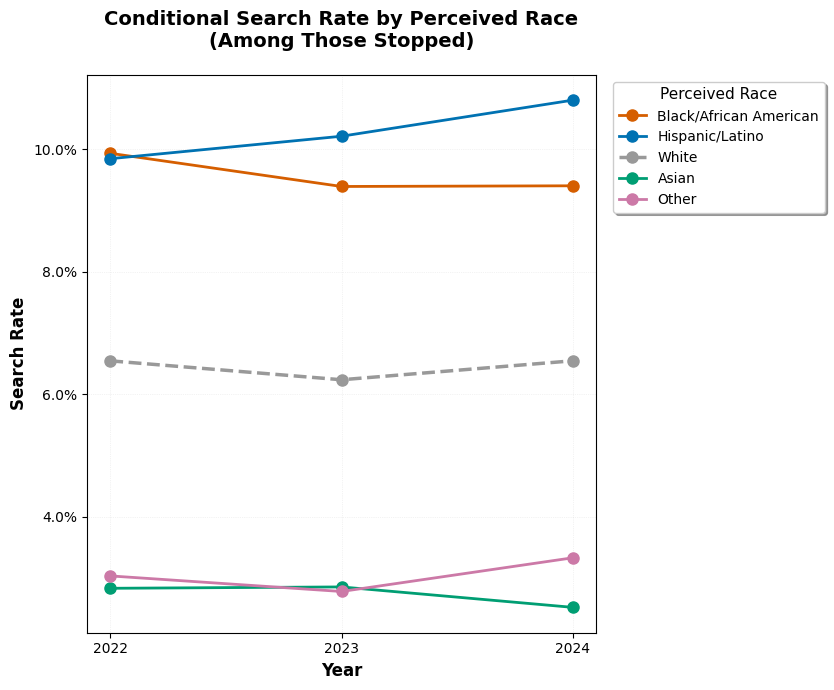

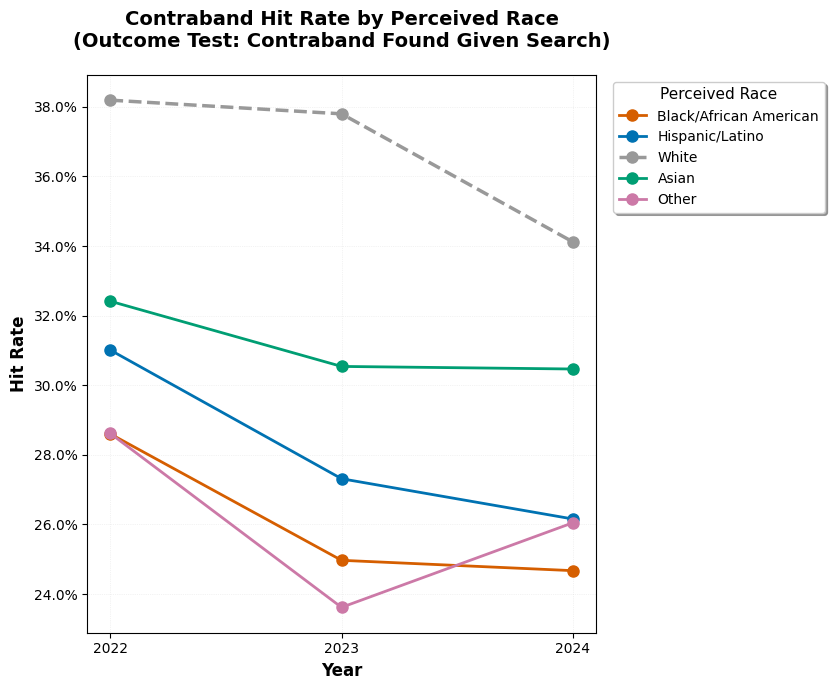

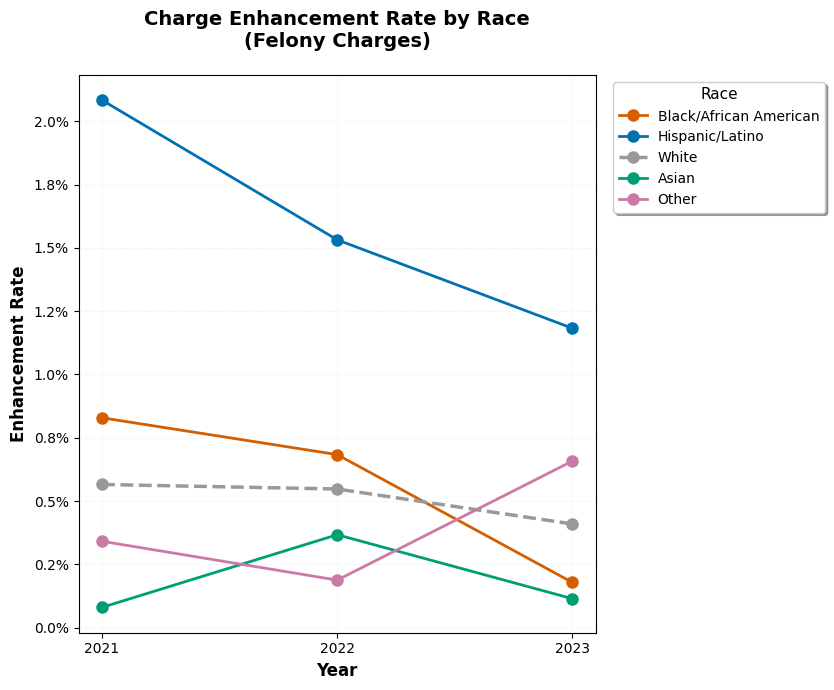

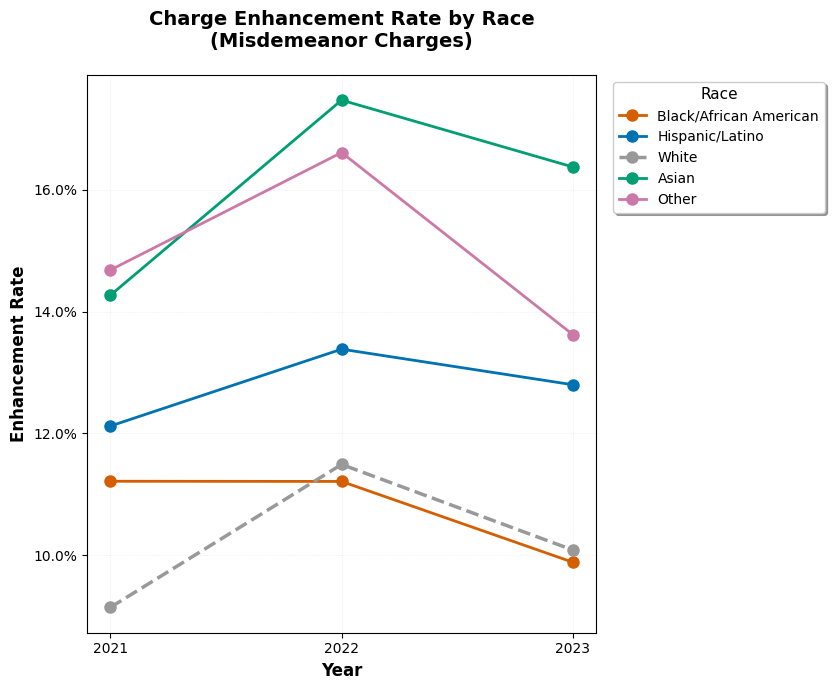

In [ ]:
from visualization_utils import(
    visualize_policing, 
    visualize_prosecution
    #,export_figures_to_pdf
)

# Generate policing visualizations
policing_figs = visualize_policing(policing_analysis)
# export_figures_to_pdf(policing_figs, output_dir='../output')

# Generate prosecution visualizations
prosecution_figs = visualize_prosecution(prosecution_analysis)
# export_figures_to_pdf(prosecution_figs, output_dir='../output')

In [ ]:
# export_tables_to_latex(policing_analysis, prosecution_analysis)

# Deeper Prosecution Analysis: Control by Charge
See Databot
- Look into why certain groups have higher rates than others – control by types of charges, starting with the most common and grouping the less common ones
- Look at the severity of charges for each group, e.g. 1st, 2nd, 3rd degree
- When get down to individual charges, get standard errors on everything – size points points by number of individuals in that bucket, then add in faint error bars to visualizations

# Sensitivity Analysis: Mixed Search Bases

Currently, I only count a search as discretionary if the search bases are purely discretional. However, for 4.79% of search cases, more than 1 search basis is recorded and contains a mix of discretionary and nondiscretionary search bases. As such, I will perform a sensitivity test to compare if including the mixed search basis stops as discretionary searches skews my results.

In [ ]:
# Check how many stops have more than one search basis

search_basis_cols = [
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory"
]

policing["num_search_bases"] = policing[search_basis_cols].sum(axis=1)
num_multi_basis = (policing["num_search_bases"] > 1).sum()
percent_multi = (policing["num_search_bases"] > 1).mean()
print(f"Only {percent_multi:.2%} of stops ({num_multi_basis}) have multiple search bases")

In [ ]:
# Create alternative classification: treat mixed searches as discretionary
policing["disc_search_mixed"] = policing["search_type"].isin(["Discretionary only", "Mixed"])
policing["disc_hit_mixed"] = policing["disc_search_mixed"] & (policing["contraband_any"] == 1)

In [ ]:
from utils import policing_rates_mixed

# Compute policing rates using mixed classification
policing_analysis_mixed = policing_rates_mixed(policing, census_coarse)
policing_analysis_mixed

## Comparing Strict vs. Mixed Classifications

In [ ]:
from utils import compare_search_classifications

# Generate comparison tables
comparison_results = compare_search_classifications(
    policing_analysis,  # strict classification
    policing_analysis_mixed  # mixed classification
)

In [ ]:
# Display 2024 comparison (most recent year)
display_cols = [
    'Perceived Race',
    'Search Count_strict',
    'Search Count_mixed',
    'Search Count % Change',
    'Search Rate_strict',
    'Search Rate_mixed',
    'Hit Rate_strict',
    'Hit Rate_mixed'
]

print("2024 COMPARISON: STRICT VS. MIXED CLASSIFICATION")
print("=" * 80)
comparison_results['summary_2024'][display_cols].round(4)

In [ ]:
# Compare disparity ratios under both approaches
print("\nDISPARITY RATIOS (relative to White baseline)")
print("=" * 80)
comparison_results['disparity_comparison'].round(3)

## Interpretation

**Key findings from sensitivity analysis:**

1. **Search count impact**: Including mixed bases increases discretionary search counts by ~37%
2. **Disparity stability**: Check if racial disparities remain similar or change significantly
3. **Hit rate patterns**: Assess whether outcome test results are robust to classification choice

**What to look for:**
- If disparity ratios are stable (±10%), the strict classification is robust
- If ratios change substantially, mixed searches may be systematically different
- Changes in hit rates could indicate different threshold levels for mixed vs. pure discretionary searches